# RQ2b — Effect of Number of Authority Peers
Sweeps n_auth ∈ {1,2,3,4,5} × authority correct/wrong. Shows how authority count and direction interact.

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from pathlib import Path

RESULTS_DIR = Path("../results_todos/rq2b")

N_AUTH = [1, 2, 3, 4, 5]
CORRECT_CONDS = [f"rq2b_auth{n}_correct" for n in N_AUTH]
WRONG_CONDS   = [f"rq2b_auth{n}_wrong"   for n in N_AUTH]
ALL_CONDS = CORRECT_CONDS + WRONG_CONDS

AUTH_LABELS = {
    **{f"rq2b_auth{n}_correct": f"{n} auth (correct)" for n in N_AUTH},
    **{f"rq2b_auth{n}_wrong":   f"{n} auth (wrong)"   for n in N_AUTH},
}

def dataset_of(csv_path):
    """Classify a metrics CSV as in-distribution (primevul) or out-of-distribution (ood_benchmark)."""
    name = csv_path.name
    if "ood_benchmark" in name:
        return "ood"
    if "primevul" in name:
        return "id"
    return None

id_dfs, ood_dfs = [], []
for csv_path in sorted(RESULTS_DIR.rglob("*.metrics.csv")):
    if "_all_seeds" in csv_path.name:
        continue
    parts = csv_path.parts
    if not any(p.startswith("seed_") for p in parts):
        continue
    dataset = dataset_of(csv_path)
    if dataset is None:
        continue
    df = pd.read_csv(csv_path)
    df = df[df["condition"].isin(ALL_CONDS + ["ALL"])]
    if df.empty:
        continue
    (id_dfs if dataset == "id" else ood_dfs).append(df)

all_per_seed = pd.concat(id_dfs, ignore_index=True) if id_dfs else pd.DataFrame()
combined = all_per_seed.groupby(["model", "condition"]).mean(numeric_only=True).reset_index()

all_per_seed_ood = pd.concat(ood_dfs, ignore_index=True) if ood_dfs else pd.DataFrame()
combined_ood = all_per_seed_ood.groupby(["model", "condition"]).mean(numeric_only=True).reset_index()

MODELS = sorted(combined["model"].unique())
PALETTE = sns.color_palette("tab10", len(MODELS))
MODEL_COLORS = dict(zip(MODELS, PALETTE))

print(f"Models: {MODELS}")
print(f"In-distribution (primevul) conditions: {sorted(combined['condition'].unique())}")
print(f"Out-of-distribution (ood_benchmark) conditions: "
      f"{sorted(combined_ood['condition'].unique()) if not combined_ood.empty else 'no OOD data found'}")


Models: ['llama31_it', 'mistral_it', 'phi35_it', 'qwen25_it']
In-distribution (primevul) conditions: ['ALL', 'rq2b_auth1_correct', 'rq2b_auth1_wrong', 'rq2b_auth2_correct', 'rq2b_auth2_wrong', 'rq2b_auth3_correct', 'rq2b_auth3_wrong', 'rq2b_auth4_correct', 'rq2b_auth4_wrong', 'rq2b_auth5_correct', 'rq2b_auth5_wrong']
Out-of-distribution (ood_benchmark) conditions: ['ALL', 'rq2b_auth1_correct', 'rq2b_auth1_wrong', 'rq2b_auth2_correct', 'rq2b_auth2_wrong', 'rq2b_auth3_correct', 'rq2b_auth3_wrong', 'rq2b_auth4_correct', 'rq2b_auth4_wrong', 'rq2b_auth5_correct', 'rq2b_auth5_wrong']


## Per-model metrics tables

In [9]:
display_cols = ["condition", "n", "acc_r1", "acc_r2", "delta_acc",
                "rev_pct", "harm_pct", "ben_pct", "mean_dC"]

for model in MODELS:
    df_m = combined[(combined["model"] == model) & (combined["condition"].isin(ALL_CONDS))].copy()
    present = [c for c in ALL_CONDS if c in df_m["condition"].values]
    df_m["condition"] = pd.Categorical(df_m["condition"], categories=present, ordered=True)
    df_m = df_m.sort_values("condition")[display_cols].reset_index(drop=True)
    print(f"\n{'─'*60}\n  {model.upper()}\n{'─'*60}")
    display(df_m.style
        .format({"n": lambda x: f"{int(x)}" if pd.notna(x) and x == int(x) else (f"{x:.2f}" if pd.notna(x) else "N/A"),
                 **{c: "{:.1f}" for c in ["acc_r1","acc_r2","delta_acc","rev_pct","harm_pct","ben_pct","mean_dC"]}}, na_rep="N/A")
        .background_gradient(subset=["delta_acc"], cmap="RdYlGn", vmin=-30, vmax=30)
        .background_gradient(subset=["harm_pct"], cmap="Reds", vmin=0, vmax=100)
        .background_gradient(subset=["ben_pct"], cmap="Greens", vmin=0, vmax=100)
        .set_caption(model))



────────────────────────────────────────────────────────────
  LLAMA31_IT
────────────────────────────────────────────────────────────


,condition,n,acc_r1,acc_r2,delta_acc,rev_pct,harm_pct,ben_pct,mean_dC
0,rq2b_auth1_correct,500,53.5,48.8,-4.7,28.9,31.4,26.1,-1.3
1,rq2b_auth2_correct,500,53.5,50.0,-3.5,28.9,30.3,27.4,-1.0
2,rq2b_auth3_correct,500,53.5,53.4,-0.1,31.1,29.2,33.4,-0.7
3,rq2b_auth4_correct,500,53.5,57.6,4.1,32.5,26.6,39.4,-0.4
4,rq2b_auth5_correct,500,53.5,57.8,4.3,33.1,26.9,40.3,-0.4
5,rq2b_auth1_wrong,500,53.5,56.2,2.7,31.9,27.3,37.2,-1.0
6,rq2b_auth2_wrong,500,53.5,53.8,0.3,30.3,28.1,33.0,-0.9
7,rq2b_auth3_wrong,500,53.5,50.2,-3.3,28.3,29.6,26.9,-0.6
8,rq2b_auth4_wrong,500,53.5,47.2,-6.3,30.5,34.4,26.1,-0.7
9,rq2b_auth5_wrong,500,53.5,47.8,-5.7,29.9,33.3,26.1,-0.7



────────────────────────────────────────────────────────────
  MISTRAL_IT
────────────────────────────────────────────────────────────


,condition,n,acc_r1,acc_r2,delta_acc,rev_pct,harm_pct,ben_pct,mean_dC
0,rq2b_auth1_correct,499,55.7,63.5,7.8,15.8,7.2,26.7,0.2
1,rq2b_auth2_correct,499.33,55.9,61.9,6.0,10.0,3.6,18.2,0.2
2,rq2b_auth3_correct,489.67,55.9,60.3,4.4,9.5,4.5,15.7,0.2
3,rq2b_auth4_correct,492.67,56.1,60.9,4.8,12.7,7.0,19.9,0.2
4,rq2b_auth5_correct,492.33,56.4,63.8,7.5,23.0,13.8,34.9,-0.1
5,rq2b_auth1_wrong,499.67,55.8,47.8,-8.0,13.6,19.4,6.3,0.3
6,rq2b_auth2_wrong,497.33,55.9,46.2,-9.7,11.3,18.7,1.8,0.2
7,rq2b_auth3_wrong,497,55.9,48.0,-7.9,11.1,16.9,3.6,0.2
8,rq2b_auth4_wrong,494,55.7,46.0,-9.7,15.4,22.5,6.4,0.2
9,rq2b_auth5_wrong,490.67,55.7,43.3,-12.4,27.6,35.9,17.2,-0.0



────────────────────────────────────────────────────────────
  PHI35_IT
────────────────────────────────────────────────────────────


,condition,n,acc_r1,acc_r2,delta_acc,rev_pct,harm_pct,ben_pct,mean_dC
0,rq2b_auth1_correct,500,50.6,45.8,-4.8,8.4,13.0,3.6,0.0
1,rq2b_auth2_correct,500,50.6,49.6,-1.0,9.0,9.9,8.1,0.0
2,rq2b_auth3_correct,500,50.6,58.1,7.5,10.7,3.2,18.4,-0.0
3,rq2b_auth4_correct,500,50.6,61.2,10.6,11.8,1.2,22.7,0.0
4,rq2b_auth5_correct,500,50.6,70.9,20.3,21.5,1.2,42.2,0.0
5,rq2b_auth1_wrong,500,50.6,58.5,7.9,9.1,1.2,17.1,-0.0
6,rq2b_auth2_wrong,500,50.6,51.0,0.4,8.0,7.5,8.5,0.0
7,rq2b_auth3_wrong,500,50.6,45.1,-5.5,9.9,15.2,4.5,0.0
8,rq2b_auth4_wrong,500,50.6,41.0,-9.6,12.1,21.5,2.6,-0.0
9,rq2b_auth5_wrong,500,50.6,27.1,-23.5,25.1,48.0,1.6,-0.0



────────────────────────────────────────────────────────────
  QWEN25_IT
────────────────────────────────────────────────────────────


,condition,n,acc_r1,acc_r2,delta_acc,rev_pct,harm_pct,ben_pct,mean_dC
0,rq2b_auth1_correct,500,59.7,50.1,-9.5,46.6,47.0,45.9,0.8
1,rq2b_auth2_correct,500,59.7,57.0,-2.7,37.3,33.5,43.0,0.8
2,rq2b_auth3_correct,500,59.7,68.1,8.4,35.1,22.3,53.9,0.9
3,rq2b_auth4_correct,500,59.7,77.2,17.5,41.1,19.8,72.7,0.8
4,rq2b_auth5_correct,500,59.7,76.0,16.3,44.9,23.9,75.9,0.9
5,rq2b_auth1_wrong,500,59.7,52.3,-7.4,44.9,43.8,46.4,0.8
6,rq2b_auth2_wrong,500,59.7,41.9,-17.7,44.3,52.0,32.9,0.8
7,rq2b_auth3_wrong,500,59.7,35.3,-24.4,43.7,57.1,24.0,0.9
8,rq2b_auth4_wrong,500,59.7,30.9,-28.8,48.5,64.8,24.5,0.8
9,rq2b_auth5_wrong,500,59.7,25.5,-34.1,57.7,77.0,29.3,0.8


## Δ Accuracy vs n_auth — correct vs wrong authority (line plot)

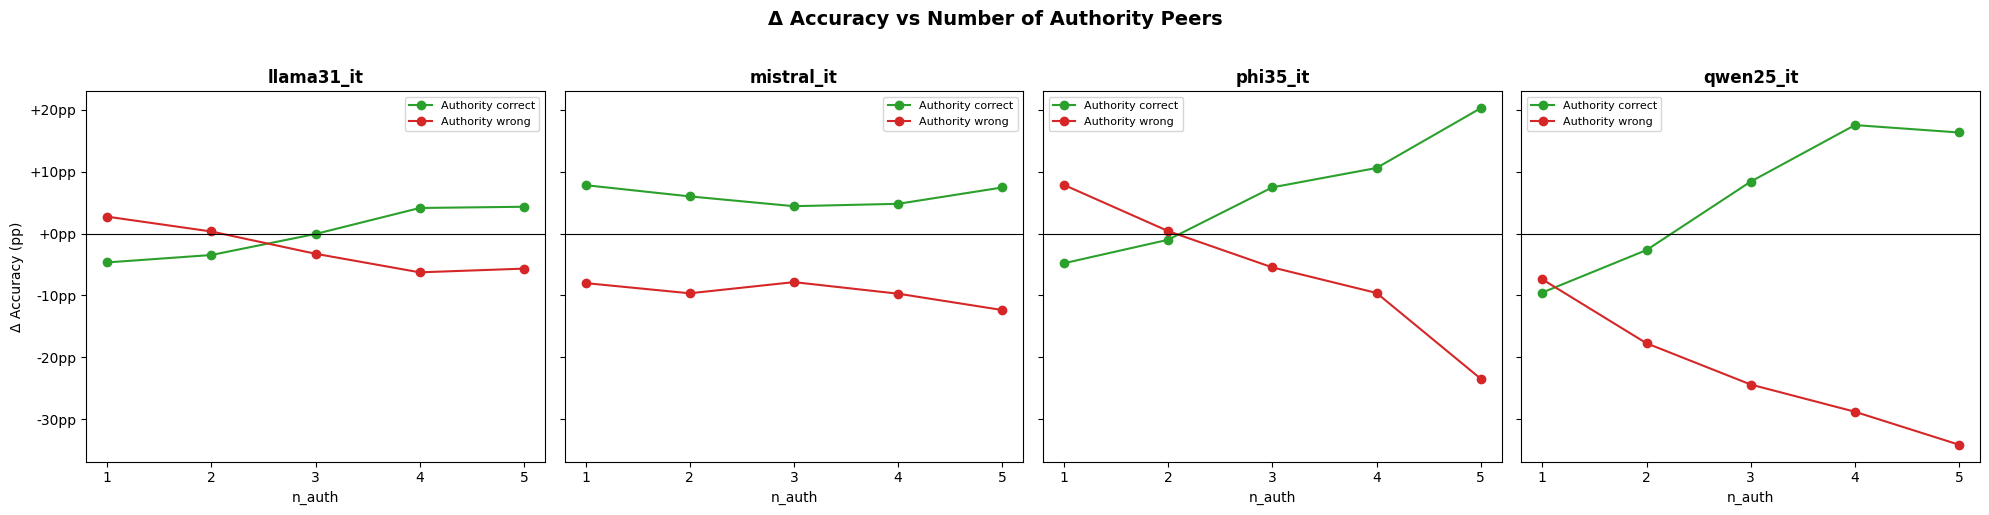

In [10]:
fig, axes = plt.subplots(1, len(MODELS), figsize=(5*len(MODELS), 5), sharey=True)
if len(MODELS) == 1:
    axes = [axes]

for ax, model in zip(axes, MODELS):
    df_m = combined[combined["model"] == model]
    for side, conds, color, label in [
        ("correct", CORRECT_CONDS, "#2ca02c", "Authority correct"),
        ("wrong",   WRONG_CONDS,   "#d62728", "Authority wrong"),
    ]:
        df_s = df_m[df_m["condition"].isin(conds)].copy()
        df_s["n_auth"] = df_s["condition"].str.extract(r"auth(\d+)").astype(int)
        df_s = df_s.sort_values("n_auth")
        ax.plot(df_s["n_auth"], df_s["delta_acc"], marker="o", color=color, label=label)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_title(model, fontsize=12, fontweight="bold")
    ax.set_xlabel("n_auth")
    ax.set_ylabel("\u0394 Accuracy (pp)" if ax == axes[0] else "")
    ax.set_xticks(N_AUTH)
    ax.legend(fontsize=8)
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"{v:+.0f}pp"))

plt.suptitle("\u0394 Accuracy vs Number of Authority Peers", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "rq2b_delta_acc_vs_nauth.png", dpi=150, bbox_inches="tight")
plt.show()


## Δ Accuracy heatmap — models × conditions

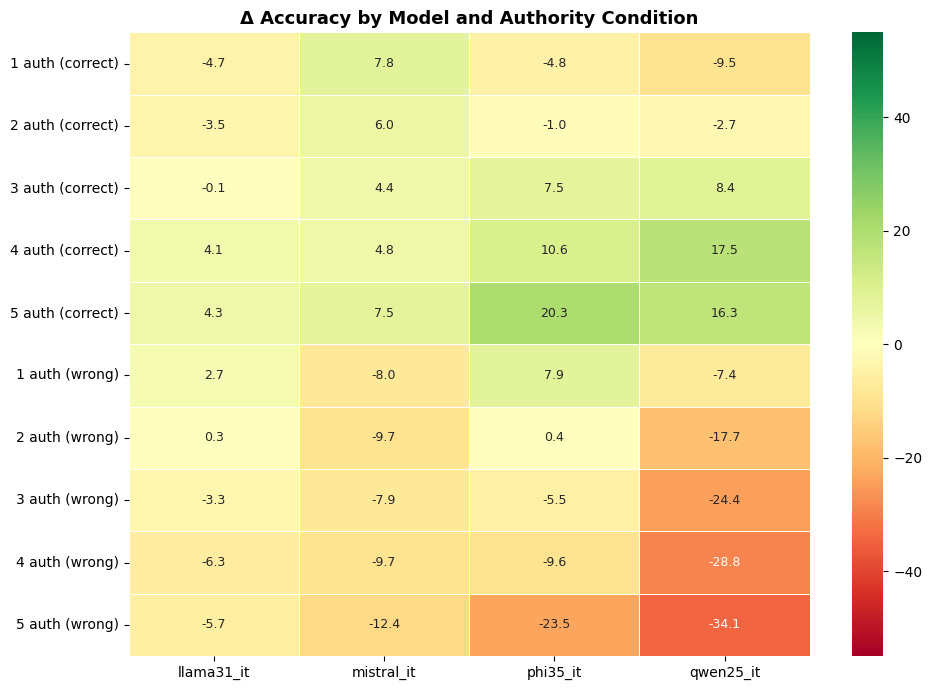

In [11]:
df_plot = combined[combined["condition"].isin(ALL_CONDS)]
pivot = df_plot.pivot_table(index="condition", columns="model", values="delta_acc")
pivot = pivot.reindex([c for c in ALL_CONDS if c in pivot.index])

fig, ax = plt.subplots(figsize=(max(6, 2.5*len(MODELS)), 7))
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="RdYlGn", center=0, vmin=-55, vmax=55,
            linewidths=0.5, ax=ax, annot_kws={"size": 9})
ax.set_title("\u0394 Accuracy by Model and Authority Condition", fontsize=13, fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("")
# FIX: human-readable y-tick labels
ax.set_yticklabels([AUTH_LABELS.get(c, c) for c in pivot.index], rotation=0)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "rq2b_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()


# Out-of-Distribution (OOD) Results

Repeats the analysis above using the `ood_benchmark_rq2b` files instead of `primevul_rq2b`, to check whether the authority-peer effect generalizes beyond the in-distribution (ID) dataset.

## Per-model metrics tables — OOD

In [12]:
if combined_ood.empty:
    print("No OOD data found.")
else:
    display_cols = ["condition", "n", "acc_r1", "acc_r2", "delta_acc",
                    "rev_pct", "harm_pct", "ben_pct", "mean_dC"]

    for model in MODELS:
        df_m = combined_ood[(combined_ood["model"] == model) & (combined_ood["condition"].isin(ALL_CONDS))].copy()
        present = [c for c in ALL_CONDS if c in df_m["condition"].values]
        df_m["condition"] = pd.Categorical(df_m["condition"], categories=present, ordered=True)
        df_m = df_m.sort_values("condition")[display_cols].reset_index(drop=True)
        print(f"\n{'─'*60}\n  {model.upper()} — OOD\n{'─'*60}")
        display(df_m.style
            .format({"n": lambda x: f"{int(x)}" if pd.notna(x) and x == int(x) else (f"{x:.2f}" if pd.notna(x) else "N/A"),
                     **{c: "{:.1f}" for c in ["acc_r1","acc_r2","delta_acc","rev_pct","harm_pct","ben_pct","mean_dC"]}}, na_rep="N/A")
            .background_gradient(subset=["delta_acc"], cmap="RdYlGn", vmin=-30, vmax=30)
            .background_gradient(subset=["harm_pct"], cmap="Reds", vmin=0, vmax=100)
            .background_gradient(subset=["ben_pct"], cmap="Greens", vmin=0, vmax=100)
            .set_caption(f"{model} — OOD"))



────────────────────────────────────────────────────────────
  LLAMA31_IT — OOD
────────────────────────────────────────────────────────────


,condition,n,acc_r1,acc_r2,delta_acc,rev_pct,harm_pct,ben_pct,mean_dC
0,rq2b_auth1_correct,500,52.9,45.8,-7.1,30.7,35.8,25.1,-1.2
1,rq2b_auth2_correct,500,52.9,46.5,-6.4,31.1,35.4,26.2,-1.0
2,rq2b_auth3_correct,500,52.9,52.5,-0.4,33.1,31.6,34.7,-0.5
3,rq2b_auth4_correct,500,52.9,56.7,3.7,36.8,31.2,43.1,-0.2
4,rq2b_auth5_correct,500,52.9,54.7,1.8,35.3,31.6,39.4,-0.1
5,rq2b_auth1_wrong,500,52.9,54.5,1.6,35.5,32.0,39.4,-0.8
6,rq2b_auth2_wrong,500,52.9,50.8,-2.1,33.2,33.4,33.0,-0.7
7,rq2b_auth3_wrong,500,52.9,45.6,-7.3,31.3,36.5,25.5,-0.5
8,rq2b_auth4_wrong,500,52.9,44.4,-8.5,31.7,38.0,24.6,-0.3
9,rq2b_auth5_wrong,500,52.9,45.1,-7.8,31.4,37.0,25.1,-0.3



────────────────────────────────────────────────────────────
  MISTRAL_IT — OOD
────────────────────────────────────────────────────────────


,condition,n,acc_r1,acc_r2,delta_acc,rev_pct,harm_pct,ben_pct,mean_dC
0,rq2b_auth1_correct,499.67,53.8,60.0,6.2,10.6,4.1,18.2,0.1
1,rq2b_auth2_correct,497,53.9,59.4,5.6,7.2,1.5,13.8,0.1
2,rq2b_auth3_correct,493,54.5,59.6,5.1,7.4,2.1,13.8,0.1
3,rq2b_auth4_correct,489,54.9,59.0,4.1,9.4,4.8,15.0,0.2
4,rq2b_auth5_correct,493.67,54.2,59.2,5.0,17.3,11.3,24.3,-0.1
5,rq2b_auth1_wrong,498.33,53.9,47.2,-6.7,10.7,16.2,4.4,0.1
6,rq2b_auth2_wrong,497.33,53.8,46.8,-7.0,8.2,14.1,1.3,0.1
7,rq2b_auth3_wrong,492.33,53.9,48.7,-5.1,8.0,12.2,3.1,0.0
8,rq2b_auth4_wrong,490.67,53.9,48.0,-5.9,11.6,16.2,6.2,0.1
9,rq2b_auth5_wrong,490.67,54.1,45.4,-8.7,18.9,25.5,11.1,-0.1



────────────────────────────────────────────────────────────
  PHI35_IT — OOD
────────────────────────────────────────────────────────────


,condition,n,acc_r1,acc_r2,delta_acc,rev_pct,harm_pct,ben_pct,mean_dC
0,rq2b_auth1_correct,500,50.2,44.9,-5.3,8.1,13.4,2.8,0.0
1,rq2b_auth2_correct,500,50.2,49.8,-0.4,8.5,8.9,8.2,0.0
2,rq2b_auth3_correct,500,50.2,55.4,5.2,9.6,4.4,14.9,0.0
3,rq2b_auth4_correct,500,50.2,59.7,9.5,11.1,1.6,20.7,0.0
4,rq2b_auth5_correct,500,50.2,68.5,18.3,19.9,1.6,38.4,-0.0
5,rq2b_auth1_wrong,500,50.2,55.9,5.7,7.3,1.6,13.0,0.0
6,rq2b_auth2_wrong,500,50.2,51.2,1.0,7.0,6.0,8.0,0.0
7,rq2b_auth3_wrong,500,50.2,46.0,-4.2,13.0,17.1,8.8,0.0
8,rq2b_auth4_wrong,500,50.2,40.3,-9.9,12.4,22.2,2.5,0.0
9,rq2b_auth5_wrong,500,50.2,28.8,-21.4,21.8,43.0,0.4,0.0



────────────────────────────────────────────────────────────
  QWEN25_IT — OOD
────────────────────────────────────────────────────────────


,condition,n,acc_r1,acc_r2,delta_acc,rev_pct,harm_pct,ben_pct,mean_dC
0,rq2b_auth1_correct,500,56.8,45.3,-11.5,46.7,51.2,40.7,0.8
1,rq2b_auth2_correct,500,56.8,57.5,0.7,39.5,34.2,46.6,0.8
2,rq2b_auth3_correct,500,56.8,69.8,13.0,35.4,19.7,56.0,0.8
3,rq2b_auth4_correct,500,56.8,78.4,21.6,38.0,14.4,69.0,0.8
4,rq2b_auth5_correct,500,56.8,80.1,23.3,44.3,18.5,78.2,0.8
5,rq2b_auth1_wrong,500,56.8,54.7,-2.1,48.1,44.1,53.2,0.8
6,rq2b_auth2_wrong,500,56.8,42.9,-13.9,41.3,48.6,31.6,0.8
7,rq2b_auth3_wrong,500,56.8,33.2,-23.6,42.4,58.1,21.8,0.8
8,rq2b_auth4_wrong,500,56.8,22.6,-34.2,46.6,71.1,14.4,0.8
9,rq2b_auth5_wrong,500,56.8,19.0,-37.8,55.4,82.0,20.4,0.8


## Δ Accuracy vs n_auth — correct vs wrong authority (line plot) — OOD

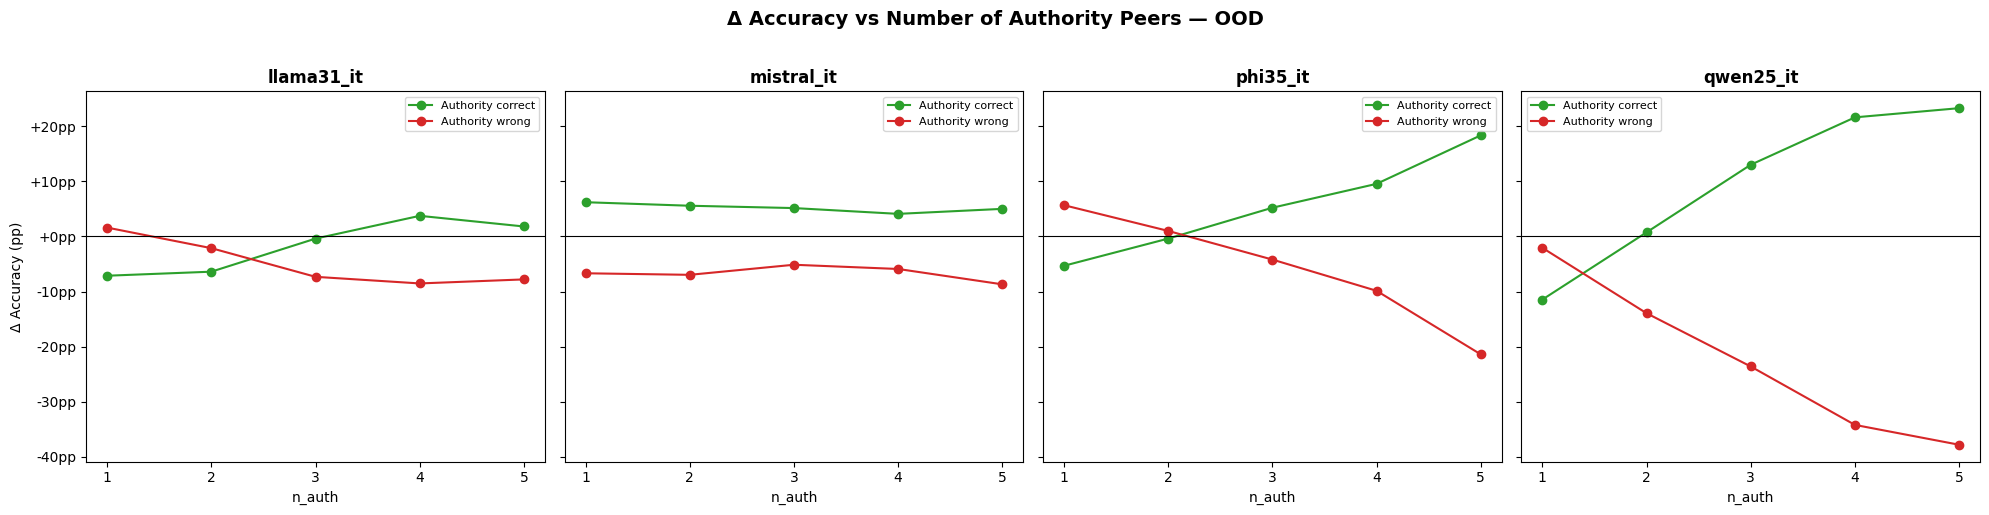

In [13]:
if combined_ood.empty:
    print("No OOD data found.")
else:
    fig, axes = plt.subplots(1, len(MODELS), figsize=(5*len(MODELS), 5), sharey=True)
    if len(MODELS) == 1:
        axes = [axes]

    for ax, model in zip(axes, MODELS):
        df_m = combined_ood[combined_ood["model"] == model]
        for side, conds, color, label in [
            ("correct", CORRECT_CONDS, "#2ca02c", "Authority correct"),
            ("wrong",   WRONG_CONDS,   "#d62728", "Authority wrong"),
        ]:
            df_s = df_m[df_m["condition"].isin(conds)].copy()
            df_s["n_auth"] = df_s["condition"].str.extract(r"auth(\d+)").astype(int)
            df_s = df_s.sort_values("n_auth")
            ax.plot(df_s["n_auth"], df_s["delta_acc"], marker="o", color=color, label=label)
        ax.axhline(0, color="black", linewidth=0.8)
        ax.set_title(model, fontsize=12, fontweight="bold")
        ax.set_xlabel("n_auth")
        ax.set_ylabel("Δ Accuracy (pp)" if ax == axes[0] else "")
        ax.set_xticks(N_AUTH)
        ax.legend(fontsize=8)
        ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"{v:+.0f}pp"))

    plt.suptitle("Δ Accuracy vs Number of Authority Peers — OOD", fontsize=14, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "rq2b_ood_delta_acc_vs_nauth.png", dpi=150, bbox_inches="tight")
    plt.show()


## Δ Accuracy heatmap — models × conditions — OOD

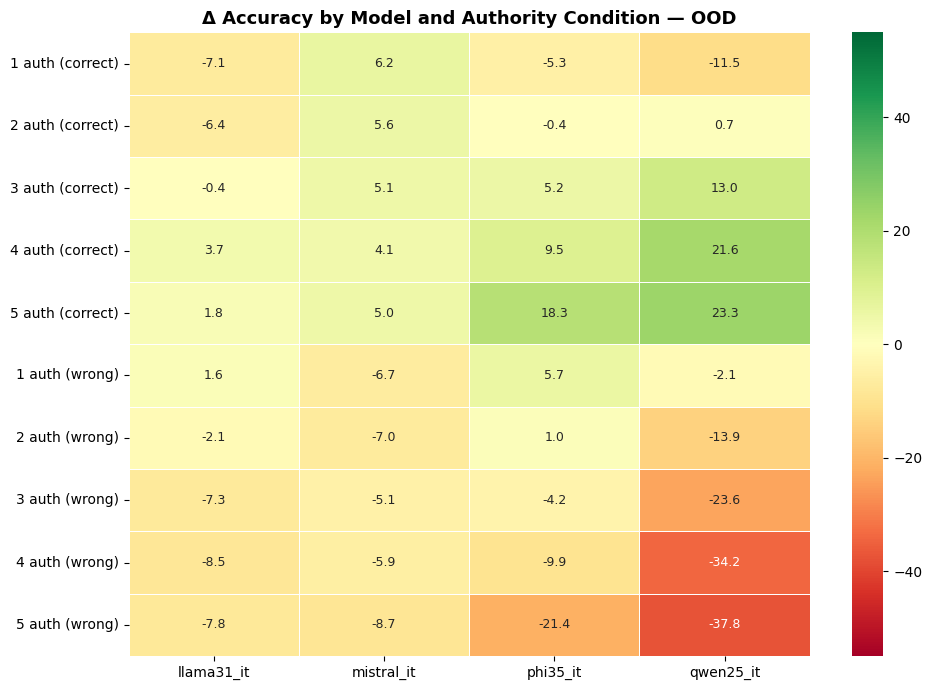

In [14]:
if combined_ood.empty:
    print("No OOD data found.")
else:
    df_plot = combined_ood[combined_ood["condition"].isin(ALL_CONDS)]
    pivot = df_plot.pivot_table(index="condition", columns="model", values="delta_acc")
    pivot = pivot.reindex([c for c in ALL_CONDS if c in pivot.index])

    fig, ax = plt.subplots(figsize=(max(6, 2.5*len(MODELS)), 7))
    sns.heatmap(pivot, annot=True, fmt=".1f", cmap="RdYlGn", center=0, vmin=-55, vmax=55,
                linewidths=0.5, ax=ax, annot_kws={"size": 9})
    ax.set_title("Δ Accuracy by Model and Authority Condition — OOD", fontsize=13, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_yticklabels([AUTH_LABELS.get(c, c) for c in pivot.index], rotation=0)
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "rq2b_ood_heatmap.png", dpi=150, bbox_inches="tight")
    plt.show()
